# Chapter 3: Global properties of curves

**Source span.** Pressley, *Elementary Differential Geometry*, Chapter 3, printed pp. 55-66 / PDF pp. 64-74, Sections 3.1-3.3.

**Chapter goal.** Turn local curve data - tangent, signed normal, signed curvature, and speed - into global tests for a closed plane curve: which side is inside, how much area it encloses, how far it is from the circular equality case, and how curvature extrema constrain closed convex curves.

This notebook is standalone. The source pages set the chapter route and terminology; all prose, diagrams, code, and numerical experiments here are original.


## Computational Translation Guide

| Book concept | Computational object in this notebook | What to inspect |
| --- | --- | --- |
| Simple closed curve | A periodic sampled planar curve plus polygon validity and winding-number probes | Closure alone is not enough; a self-crossing loop fails the simple-curve test. |
| Positive orientation | Positive signed area and the left signed normal pointing to the bounded side | Reversing the parameter flips the sign of the Green area integral. |
| Interior and exterior | Winding number of test points, with Shapely used only as a numerical validity check | Interior probes have winding number near 1; exterior probes have winding number near 0. |
| Green area formula | A line integral `1/2 int (x ydot - y xdot) dt` compared with the shoelace and polygon areas | The same area is recovered from boundary data, not by rasterizing the region. |
| Isoperimetric inequality | `Q = 4 pi A / L^2 <= 1` and roundness deficit `delta = L^2/(4 pi A)-1` | Circles sit at `Q=1`; distortions lower `Q` and increase `delta`. |
| Wirtinger step | A nonnegative decomposition of Pressley's proof quantity into radial and angular residuals | Equality forces one sine radial mode and unit angular speed. |
| Vertex | A local extremum of signed curvature along a regular curve | Convex simple closed examples show at least four; a self-crossing closed curve is a warning about hypotheses. |


## Standalone Reading Guide

Chapter 3 changes scale from local curvature to whole closed curves. A simple closed curve has an inside, an orientation, an enclosed area, and global inequalities that cannot be seen from a single point. The notebook makes those global quantities executable: it samples closed curves, checks orientation, computes area through a Green-style integral, and compares perimeter with area through the isoperimetric quotient.

The isoperimetric visuals are deliberately diagnostic rather than decorative. A circle is the equality case, and every perturbation raises the roundness deficit. The Wirtinger-style panel shows how that inequality can be decomposed into modes, so the deficit becomes something measurable in the curve's Fourier-like shape content. The curvature-extrema and four-vertex experiments then ask a different global question: even when the curve is smooth and convex, curvature must rise and fall enough times to create at least four vertices.

The applied lab uses synthetic ovals and near-self-crossing curves so the reader can see where hypotheses matter. Area formulas, roundness metrics, winding behavior, and vertex counts are useful only after the curve's simplicity and orientation have been checked. The final sanity cell therefore treats geometric assumptions and numerical invariants as one contract.


## Route Through The Chapter

1. Build simple and non-simple closed loops and test orientation, winding, and total turning.
2. Compute area from the boundary using Green's theorem and verify the result against polygon area.
3. Compare curves through the isoperimetric quotient and a roundness-deficit sweep.
4. Expose the proof bookkeeping behind the isoperimetric inequality via a Wirtinger residual.
5. Locate curvature extrema and run four-vertex experiments on convex and self-crossing curves.
6. Finish with an applied lab table and sanity checks that validate artifacts and numerical invariants.


In [1]:
from __future__ import annotations

import json
import math
import sys
from pathlib import Path

BOOK_FOLDER = "Elementary-Differential-Geometry-Andrew-Pressley"

def find_book_root() -> Path:
    here = Path.cwd().resolve()
    candidates = [here, here / BOOK_FOLDER]
    candidates.extend(here.parents)
    candidates.extend(parent / BOOK_FOLDER for parent in [here, *here.parents])
    for candidate in candidates:
        if (candidate / "00-book-index.ipynb").exists() and (candidate / "utils").is_dir():
            return candidate.resolve()
    raise FileNotFoundError("Could not locate the Pressley book root")

BOOK_ROOT = find_book_root()
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import assert_artifact, display_artifact

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import sympy as sp
from IPython.display import Markdown, display
from matplotlib import pyplot as plt
from scipy.signal import find_peaks
from shapely.geometry import LineString, Polygon
from shapely.validation import explain_validity

UNIT = "chapter-03"
NOTEBOOK_PATH = BOOK_ROOT / "chapter-03-global-properties-of-curves" / "03-global-properties-of-curves.ipynb"
ARTIFACT_DIR = BOOK_ROOT / "artifacts" / UNIT
FIGURE_DIR = ARTIFACT_DIR / "figures"
CHECK_DIR = ARTIFACT_DIR / "checks"
TABLE_DIR = ARTIFACT_DIR / "tables"
INTERACTIVE_DIR = ARTIFACT_DIR / "interactive"
for directory in [FIGURE_DIR, CHECK_DIR, TABLE_DIR, INTERACTIVE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

SOURCE_SPAN = {"printed": "55-66", "pdf": "64-74", "sections": "3.1-3.3"}
(CHECK_DIR / "source-span.json").write_text(json.dumps(SOURCE_SPAN, indent=2, sort_keys=True), encoding="utf-8")

VISUAL_STORYBOARD = {
    "chapter_goal": "Use global boundary data to inspect simple closed curves, area, isoperimetry, and curvature vertices.",
    "source_span": SOURCE_SPAN,
    "library_routing": [
        {"concept": "simple closed curve, orientation, winding", "library": "NumPy, Shapely, Matplotlib", "why": "sampled curve predicates and durable labeled 2D diagrams"},
        {"concept": "Green area computation", "library": "SymPy, NumPy, Matplotlib", "why": "exact ellipse check plus numerical boundary integral visualization"},
        {"concept": "isoperimetric quotient and roundness deficit", "library": "NumPy, Matplotlib, Plotly", "why": "static comparisons plus an interactive parameter sweep"},
        {"concept": "Wirtinger proof scaffold", "library": "NumPy, Matplotlib", "why": "nonnegative residual terms are visible as plotted functions and bars"},
        {"concept": "curvature extrema and four-vertex experiments", "library": "SciPy, NumPy, Shapely, Matplotlib", "why": "robust periodic extrema detection and hypothesis checks"},
    ],
    "visual_sequence": [
        {"artifact": "figures/simple-closed-orientation-winding.png", "inspection_target": "interior/exterior probes, inward normal, and self-crossing failure"},
        {"artifact": "figures/oriented-area-green-computation.png", "inspection_target": "signed Green density and cumulative area"},
        {"artifact": "figures/isoperimetric-roundness-deficit.png", "inspection_target": "same-area shapes, quotient bars, and deficit heatmap"},
        {"artifact": "interactive/roundness-deficit-family.html", "inspection_target": "parameter sweep showing Q decrease under a radial perturbation"},
        {"artifact": "figures/isoperimetric-proof-decomposition.png", "inspection_target": "Wirtinger and angular residuals in equality and perturbed cases"},
        {"artifact": "figures/four-vertex-curvature-extrema.png", "inspection_target": "detected curvature extrema on convex and self-crossing examples"},
        {"artifact": "figures/four-vertex-integral-ledger.png", "inspection_target": "periodic primitive behind the four-vertex proof contradiction"},
    ],
    "computational_checks": [
        "source span metadata",
        "artifact existence and nonzero size",
        "Green area residuals",
        "isoperimetric quotient bounds",
        "Wirtinger residual signs",
        "four-vertex counts for convex examples",
        "absence of generic visual-builder calls",
    ],
}
(CHECK_DIR / "visual-storyboard.json").write_text(json.dumps(VISUAL_STORYBOARD, indent=2, sort_keys=True), encoding="utf-8")

TWO_PI = 2.0 * np.pi
plt.rcParams.update({
    "figure.figsize": (8.5, 5.2),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

def book_rel(path: str | Path) -> str:
    return Path(path).resolve().relative_to(BOOK_ROOT).as_posix()

def display_book_artifact(path: str | Path, **kwargs):
    path = Path(path).resolve()
    try:
        display_path = path.relative_to(Path.cwd().resolve())
    except ValueError:
        display_path = path
    return display_artifact(display_path, **kwargs)

def save_json_artifact(data: dict, filename: str) -> Path:
    path = CHECK_DIR / filename
    path.write_text(json.dumps(data, indent=2, sort_keys=True), encoding="utf-8")
    return path

print(f"Book root detected: {BOOK_ROOT.name}")
print(f"Artifacts will be written under {book_rel(ARTIFACT_DIR)}")


Book root detected: Elementary-Differential-Geometry-Andrew-Pressley
Artifacts will be written under artifacts/chapter-03


In [2]:
def close_points(points: np.ndarray) -> np.ndarray:
    points = np.asarray(points, dtype=float)
    if len(points) == 0 or np.linalg.norm(points[0] - points[-1]) < 1e-12:
        return points.copy()
    return np.vstack([points, points[0]])

def signed_area(points: np.ndarray) -> float:
    p = close_points(points)
    return 0.5 * float(np.sum(p[:-1, 0] * p[1:, 1] - p[1:, 0] * p[:-1, 1]))

def perimeter(points: np.ndarray) -> float:
    p = close_points(points)
    return float(np.sum(np.linalg.norm(np.diff(p, axis=0), axis=1)))

def winding_number(points: np.ndarray, probe: tuple[float, float]) -> float:
    p = close_points(points)
    vectors = p - np.asarray(probe, dtype=float)
    angles = np.unwrap(np.arctan2(vectors[:, 1], vectors[:, 0]))
    return float((angles[-1] - angles[0]) / TWO_PI)

def polygon_validity(points: np.ndarray) -> dict:
    poly = Polygon(close_points(points))
    line = LineString(close_points(points))
    return {
        "polygon_valid": bool(poly.is_valid),
        "boundary_simple": bool(line.is_simple),
        "area_abs": float(abs(poly.area)),
        "validity_note": explain_validity(poly),
    }

def periodic_derivatives(values: np.ndarray, step: float) -> tuple[np.ndarray, np.ndarray]:
    values = np.asarray(values, dtype=float)
    first = (np.roll(values, -1) - np.roll(values, 1)) / (2.0 * step)
    second = (np.roll(values, -1) - 2.0 * values + np.roll(values, 1)) / (step * step)
    return first, second

def curvature_from_points(points: np.ndarray, t: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    step = float(t[1] - t[0])
    x = points[:, 0]
    y = points[:, 1]
    dx, ddx = periodic_derivatives(x, step)
    dy, ddy = periodic_derivatives(y, step)
    speed = np.hypot(dx, dy)
    kappa = (dx * ddy - dy * ddx) / np.maximum(speed, 1e-14) ** 3
    return kappa, speed

def unit_tangent_normal(points: np.ndarray, t: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    step = float(t[1] - t[0])
    dx, _ = periodic_derivatives(points[:, 0], step)
    dy, _ = periodic_derivatives(points[:, 1], step)
    speed = np.maximum(np.hypot(dx, dy), 1e-14)
    tangent = np.column_stack([dx / speed, dy / speed])
    left_normal = np.column_stack([-tangent[:, 1], tangent[:, 0]])
    return tangent, left_normal, speed

def total_turn(points: np.ndarray, t: np.ndarray) -> float:
    tangent, _, _ = unit_tangent_normal(points, t)
    next_tangent = np.roll(tangent, -1, axis=0)
    cross = tangent[:, 0] * next_tangent[:, 1] - tangent[:, 1] * next_tangent[:, 0]
    dot = np.sum(tangent * next_tangent, axis=1)
    return float(np.sum(np.arctan2(cross, dot)))

def isoperimetric_metrics(points: np.ndarray) -> dict:
    area = abs(signed_area(points))
    length = perimeter(points)
    quotient = 4.0 * np.pi * area / (length * length)
    deficit = (length * length) / (4.0 * np.pi * area) - 1.0 if area > 0 else math.inf
    poly = Polygon(close_points(points))
    hull_area = poly.convex_hull.area if not poly.is_empty else math.nan
    return {
        "signed_area": signed_area(points),
        "area": area,
        "length": length,
        "isoperimetric_quotient": quotient,
        "roundness_deficit": deficit,
        "convexity_area_ratio": float(area / hull_area) if hull_area else math.nan,
    }

def periodic_extrema_indices(values: np.ndarray, *, prominence_fraction: float = 0.02, distance_fraction: float = 1 / 32) -> np.ndarray:
    values = np.asarray(values, dtype=float)
    n = len(values)
    span = float(np.max(values) - np.min(values))
    if span < 1e-10:
        return np.array([], dtype=int)
    prominence = max(1e-8, prominence_fraction * span)
    distance = max(1, int(n * distance_fraction))
    tiled = np.r_[values, values, values]
    peaks, _ = find_peaks(tiled, prominence=prominence, distance=distance)
    troughs, _ = find_peaks(-tiled, prominence=prominence, distance=distance)
    center = []
    for idx in np.r_[peaks, troughs]:
        if n <= idx < 2 * n:
            center.append(int(idx - n))
    return np.array(sorted(set(center)), dtype=int)

def radial_curve(t: np.ndarray, *, base: float = 1.0, terms: list[tuple[float, int, float]] | None = None) -> np.ndarray:
    r = np.full_like(t, base, dtype=float)
    for amplitude, frequency, phase in terms or []:
        r += amplitude * np.cos(frequency * t + phase)
    return np.column_stack([r * np.cos(t), r * np.sin(t)])

def circle_curve(t: np.ndarray, radius: float = 1.0) -> np.ndarray:
    return np.column_stack([radius * np.cos(t), radius * np.sin(t)])

def ellipse_curve(t: np.ndarray, a: float = 1.6, b: float = 0.75) -> np.ndarray:
    return np.column_stack([a * np.cos(t), b * np.sin(t)])

def limacon_curve(t: np.ndarray, a: float = 1.35) -> np.ndarray:
    r = 1.0 + a * np.cos(t)
    return np.column_stack([r * np.cos(t), r * np.sin(t)])

def support_oval(t: np.ndarray, a: float = 0.05, b: float = 0.09) -> tuple[np.ndarray, np.ndarray]:
    h = 1.0 + a * np.cos(3.0 * t) + b * np.sin(2.0 * t)
    hp = -3.0 * a * np.sin(3.0 * t) + 2.0 * b * np.cos(2.0 * t)
    hpp = -9.0 * a * np.cos(3.0 * t) - 4.0 * b * np.sin(2.0 * t)
    normal = np.column_stack([np.cos(t), np.sin(t)])
    tangent = np.column_stack([-np.sin(t), np.cos(t)])
    points = h[:, None] * normal + hp[:, None] * tangent
    radius_of_curvature = h + hpp
    return points, radius_of_curvature

def normalize_to_area(points: np.ndarray, target_area: float = np.pi) -> np.ndarray:
    factor = math.sqrt(target_area / abs(signed_area(points)))
    return points * factor


## 3.1 Simple Closed Curves, Orientation, And Winding

A closed formula such as `gamma(0)=gamma(T)` does not tell us whether the trace is simple. The first figure compares a nonconvex but simple loop with a self-crossing closed loop. The visual tests are deliberately global: polygon validity, boundary simplicity, winding of selected points, and total turning of the tangent.

For a positively oriented simple closed curve in Pressley's convention, the signed normal is the left normal and points into the bounded side. In the plot, tangent arrows follow the parameter and short normal arrows point into the filled region.


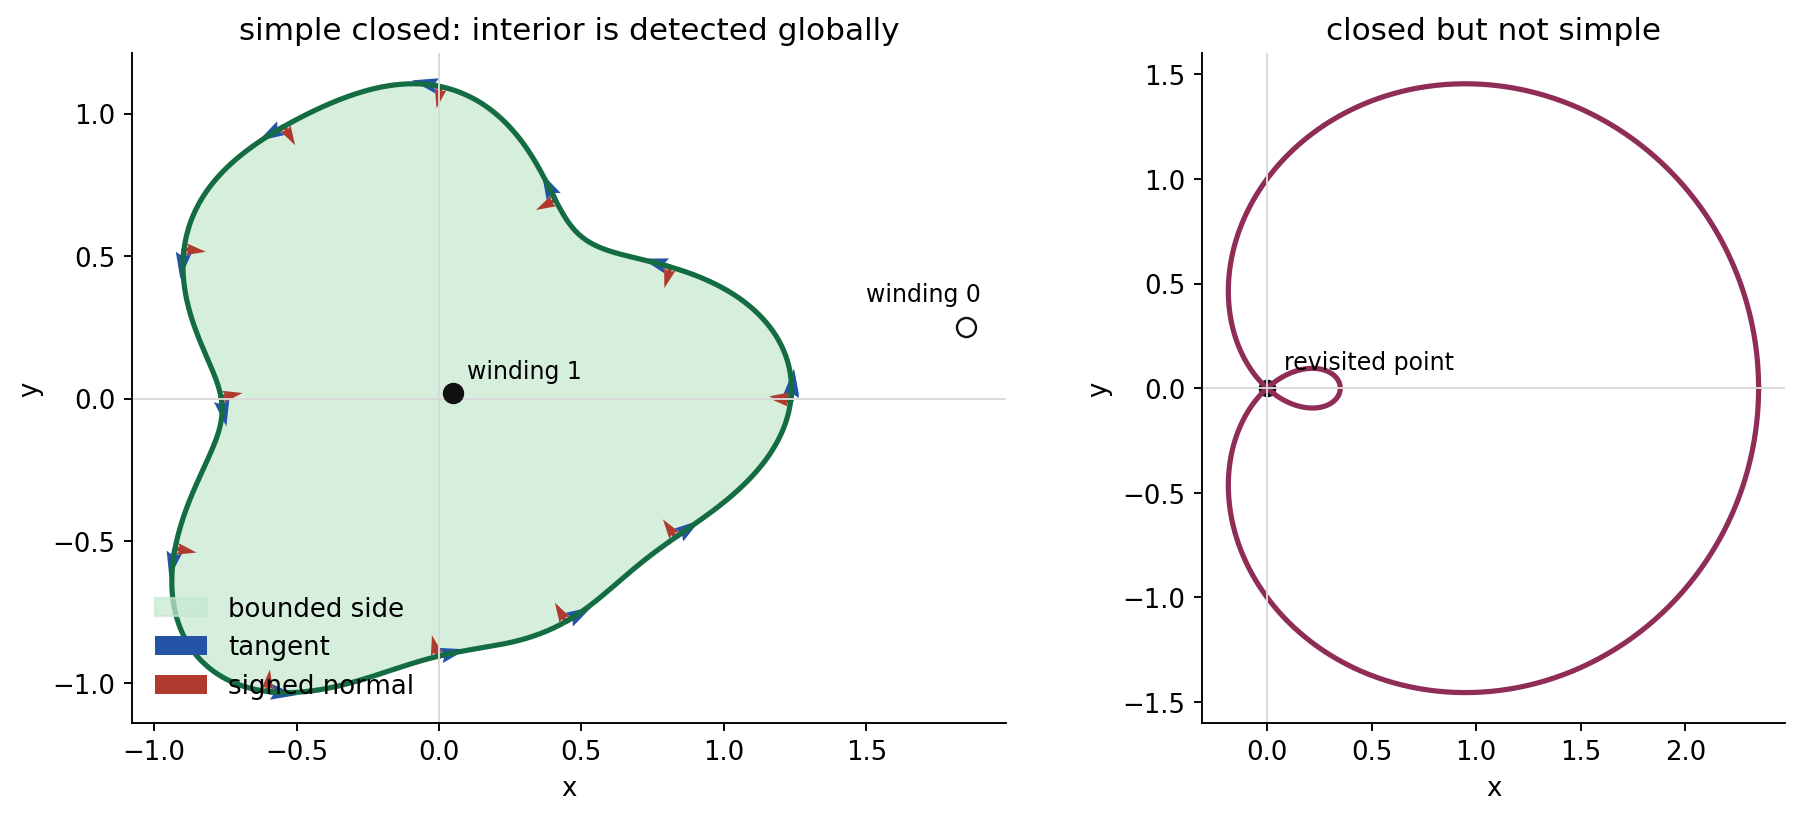

Checks saved to `artifacts/chapter-03/checks/simple-closed-orientation.json`

In [3]:
t = np.linspace(0.0, TWO_PI, 900, endpoint=False)
simple_points = radial_curve(t, terms=[(0.18, 3, 0.25), (0.08, 5, -0.7)])
self_crossing_points = limacon_curve(t, a=1.35)
inside_probe = (0.05, 0.02)
outside_probe = (1.85, 0.25)

simple_check = {
    "artifact": "figures/simple-closed-orientation-winding.png",
    "simple_loop": polygon_validity(simple_points),
    "self_crossing_loop": polygon_validity(self_crossing_points),
    "inside_probe_winding": winding_number(simple_points, inside_probe),
    "outside_probe_winding": winding_number(simple_points, outside_probe),
    "simple_signed_area": signed_area(simple_points),
    "simple_total_turn": total_turn(simple_points, t),
    "self_crossing_total_turn": total_turn(self_crossing_points, t),
}
simple_check_path = save_json_artifact(simple_check, "simple-closed-orientation.json")

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.7), constrained_layout=True)
ax = axes[0]
closed_simple = close_points(simple_points)
ax.fill(closed_simple[:, 0], closed_simple[:, 1], color="#c7e9d1", alpha=0.72, label="bounded side")
ax.plot(closed_simple[:, 0], closed_simple[:, 1], color="#146c43", lw=2.2)
idx = np.linspace(0, len(t) - 1, 13, dtype=int)
tangent, normal, _ = unit_tangent_normal(simple_points, t)
ax.quiver(simple_points[idx, 0], simple_points[idx, 1], tangent[idx, 0], tangent[idx, 1], angles="xy", scale_units="xy", scale=9.5, color="#2454a6", width=0.006, label="tangent")
ax.quiver(simple_points[idx, 0], simple_points[idx, 1], normal[idx, 0], normal[idx, 1], angles="xy", scale_units="xy", scale=13.0, color="#b03a2e", width=0.0045, label="signed normal")
ax.scatter(*inside_probe, s=65, color="#111111", zorder=4)
ax.text(inside_probe[0] + 0.05, inside_probe[1] + 0.05, "winding 1", fontsize=10)
ax.scatter(*outside_probe, s=65, color="#111111", facecolor="white", zorder=4)
ax.text(outside_probe[0] - 0.35, outside_probe[1] + 0.09, "winding 0", fontsize=10)
ax.set_title("simple closed: interior is detected globally")
ax.set_aspect("equal")
ax.legend(loc="lower left", frameon=False)

ax = axes[1]
closed_crossing = close_points(self_crossing_points)
ax.plot(closed_crossing[:, 0], closed_crossing[:, 1], color="#8f2d56", lw=2.2)
ax.scatter([0], [0], s=42, color="#111111")
ax.text(0.08, 0.09, "revisited point", fontsize=10)
ax.set_title("closed but not simple")
ax.set_aspect("equal")

for ax in axes:
    ax.axhline(0, color="0.85", lw=0.8)
    ax.axvline(0, color="0.85", lw=0.8)
    ax.set_xlabel("x")
    ax.set_ylabel("y")

simple_orientation_path = FIGURE_DIR / "simple-closed-orientation-winding.png"
fig.savefig(simple_orientation_path, dpi=170, bbox_inches="tight")
plt.close(fig)

display_book_artifact(simple_orientation_path, width=920)
Markdown(f"Checks saved to `{book_rel(simple_check_path)}`")


## 3.2 Oriented Area From The Boundary

Green's theorem lets the area of the bounded side be recovered from the boundary. The useful computational form is

\[
A = \frac12\int (x\,dy-y\,dx),
\]

with sign determined by orientation. The next cell checks the formula exactly for an ellipse, then the figure compares three numerical area computations on a less symmetric simple curve.


In [4]:
sym_t, p, q = sp.symbols("t p q", positive=True)
x_expr = p * sp.cos(sym_t)
y_expr = q * sp.sin(sym_t)
area_density_expr = sp.simplify(sp.Rational(1, 2) * (x_expr * sp.diff(y_expr, sym_t) - y_expr * sp.diff(x_expr, sym_t)))
ellipse_area_expr = sp.integrate(area_density_expr, (sym_t, 0, 2 * sp.pi))
curvature_expr = sp.simplify(
    (sp.diff(x_expr, sym_t) * sp.diff(y_expr, sym_t, 2) - sp.diff(y_expr, sym_t) * sp.diff(x_expr, sym_t, 2))
    / (sp.diff(x_expr, sym_t) ** 2 + sp.diff(y_expr, sym_t) ** 2) ** sp.Rational(3, 2)
)
curvature_derivative_expr = sp.factor(sp.diff(curvature_expr, sym_t))

symbolic_check = {
    "ellipse_area_density": str(area_density_expr),
    "ellipse_area_integral": str(ellipse_area_expr),
    "ellipse_curvature": str(curvature_expr),
    "ellipse_curvature_derivative": str(curvature_derivative_expr),
    "area_equals_pi_p_q": bool(sp.simplify(ellipse_area_expr - sp.pi * p * q) == 0),
}
symbolic_check_path = save_json_artifact(symbolic_check, "ellipse-symbolic-green-curvature.json")
assert symbolic_check["area_equals_pi_p_q"]

display(Markdown(rf"For the ellipse, SymPy gives area density `${sp.latex(area_density_expr)}$`, so the boundary integral over one period is `${sp.latex(ellipse_area_expr)}$`."))
display(Markdown(rf"The same exact calculation gives signed curvature `${sp.latex(curvature_expr)}$`, whose derivative has the expected sine-cosine factors: `${sp.latex(curvature_derivative_expr)}$`."))


For the ellipse, SymPy gives area density `$\frac{p q}{2}$`, so the boundary integral over one period is `$\pi p q$`.

The same exact calculation gives signed curvature `$\frac{p q}{\left(p^{2} \sin^{2}{\left(t \right)} + q^{2} \cos^{2}{\left(t \right)}\right)^{\frac{3}{2}}}$`, whose derivative has the expected sine-cosine factors: `$- \frac{3 p q \left(p - q\right) \left(p + q\right) \sin{\left(t \right)} \cos{\left(t \right)}}{\left(p^{2} \sin^{2}{\left(t \right)} + q^{2} \cos^{2}{\left(t \right)}\right)^{\frac{5}{2}}}$`.

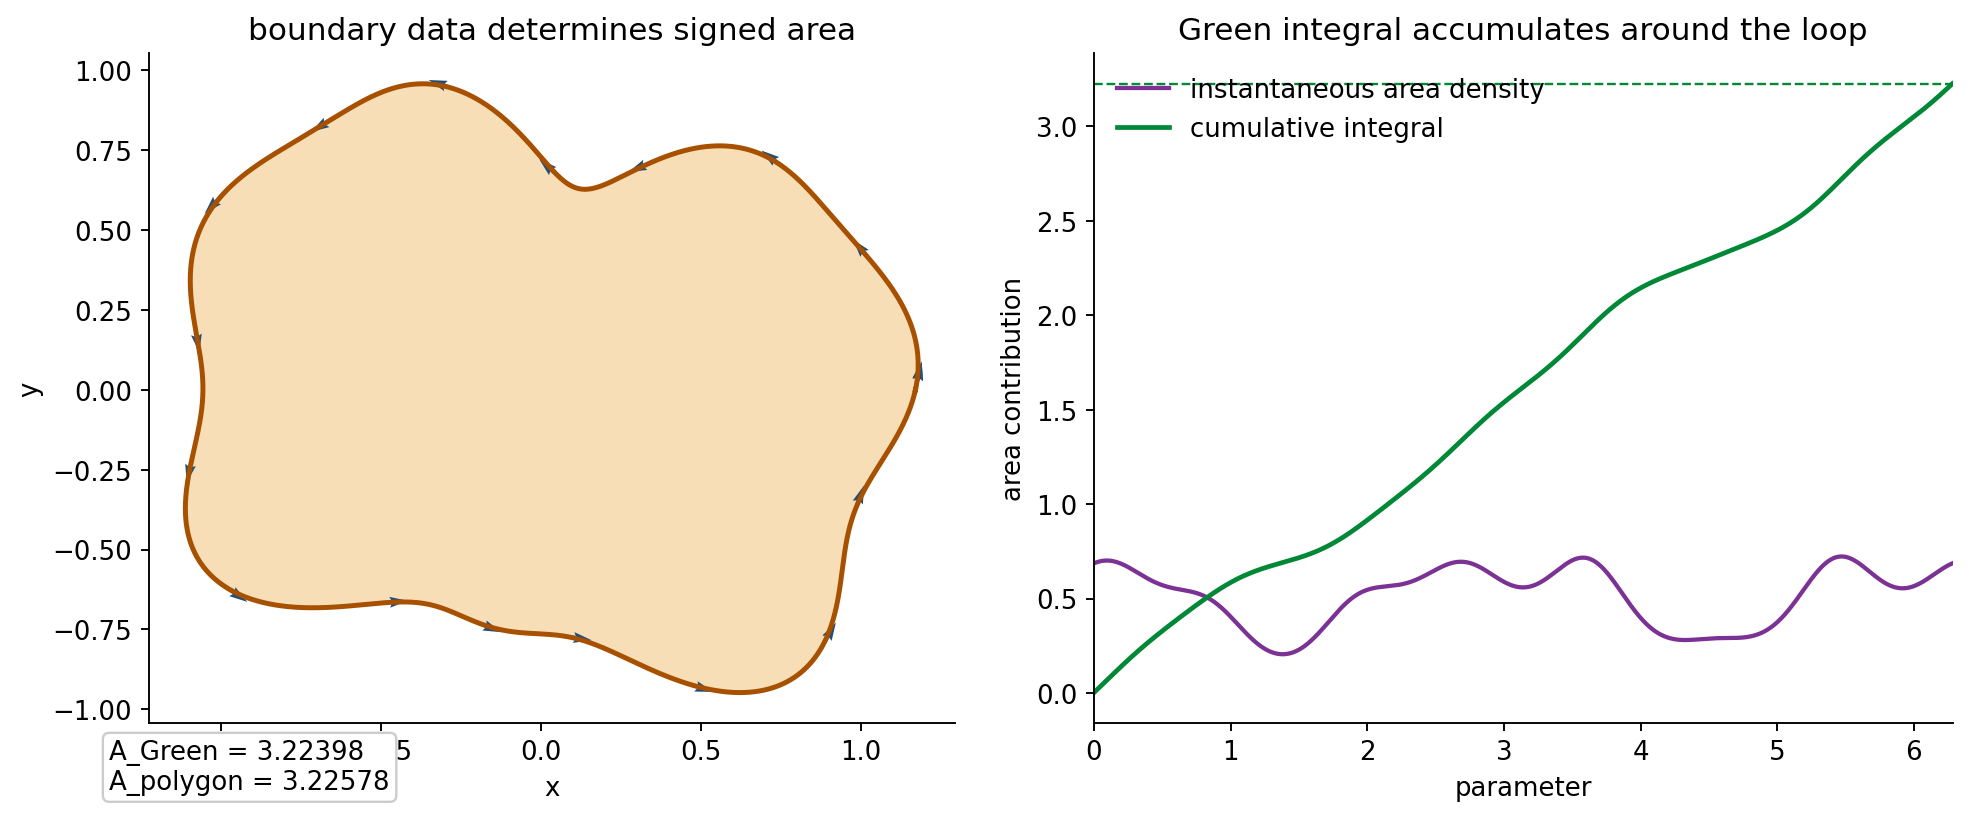

Checks saved to `artifacts/chapter-03/checks/green-area-computation.json`

In [5]:
dense_t = np.linspace(0.0, TWO_PI, 2400, endpoint=False)
green_points = radial_curve(dense_t, terms=[(0.20, 2, 0.4), (-0.10, 4, 0.8), (0.06, 7, -0.3)])
step = float(dense_t[1] - dense_t[0])
dx, _ = periodic_derivatives(green_points[:, 0], step)
dy, _ = periodic_derivatives(green_points[:, 1], step)
green_density = 0.5 * (green_points[:, 0] * dy - green_points[:, 1] * dx)
green_area = float(np.trapezoid(green_density, dense_t))
shoelace_area = signed_area(green_points)
polygon_area = float(Polygon(close_points(green_points)).area)
reverse_green_area = -green_area
cumulative_area = np.cumsum(green_density) * step

area_check = {
    "artifact": "figures/oriented-area-green-computation.png",
    "green_area": green_area,
    "shoelace_area": shoelace_area,
    "polygon_area": polygon_area,
    "reverse_orientation_area": reverse_green_area,
    "green_minus_shoelace": green_area - shoelace_area,
    "shoelace_minus_polygon_abs": abs(abs(shoelace_area) - polygon_area),
}
area_check_path = save_json_artifact(area_check, "green-area-computation.json")

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.7), constrained_layout=True)
ax = axes[0]
p_closed = close_points(green_points)
ax.fill(p_closed[:, 0], p_closed[:, 1], color="#f6d7a7", alpha=0.82)
ax.plot(p_closed[:, 0], p_closed[:, 1], color="#a65000", lw=2.1)
arrow_idx = np.linspace(0, len(dense_t) - 1, 18, dtype=int)
tangent, _, _ = unit_tangent_normal(green_points, dense_t)
ax.quiver(green_points[arrow_idx, 0], green_points[arrow_idx, 1], tangent[arrow_idx, 0], tangent[arrow_idx, 1], angles="xy", scale_units="xy", scale=11, color="#1f4e79", width=0.0045)
ax.set_title("boundary data determines signed area")
ax.set_aspect("equal")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.text(-1.35, -1.25, f"A_Green = {green_area:.5f}\nA_polygon = {polygon_area:.5f}", bbox={"boxstyle": "round,pad=0.25", "facecolor": "white", "edgecolor": "0.8"})

ax = axes[1]
ax.plot(dense_t, green_density, color="#7b3294", lw=1.8, label="instantaneous area density")
ax.plot(dense_t, cumulative_area, color="#008837", lw=2.0, label="cumulative integral")
ax.axhline(green_area, color="#008837", lw=1.0, ls="--")
ax.set_xlim(0, TWO_PI)
ax.set_xlabel("parameter")
ax.set_ylabel("area contribution")
ax.set_title("Green integral accumulates around the loop")
ax.legend(frameon=False)

area_path = FIGURE_DIR / "oriented-area-green-computation.png"
fig.savefig(area_path, dpi=170, bbox_inches="tight")
plt.close(fig)

display_book_artifact(area_path, width=920)
Markdown(f"Checks saved to `{book_rel(area_check_path)}`")


## Isoperimetry And Roundness Deficit

The isoperimetric theorem says that the circle is the unique equality case for `A <= L^2/(4 pi)`. Numerically it is better to track the dimensionless quotient

\[
Q=\frac{4\pi A}{L^2}
\]

and the roundness deficit

\[
\delta=\frac{L^2}{4\pi A}-1.
\]

Both are scale-invariant. The next figure normalizes several curves to the same area, so the increased perimeter of noncircular shapes is directly visible.


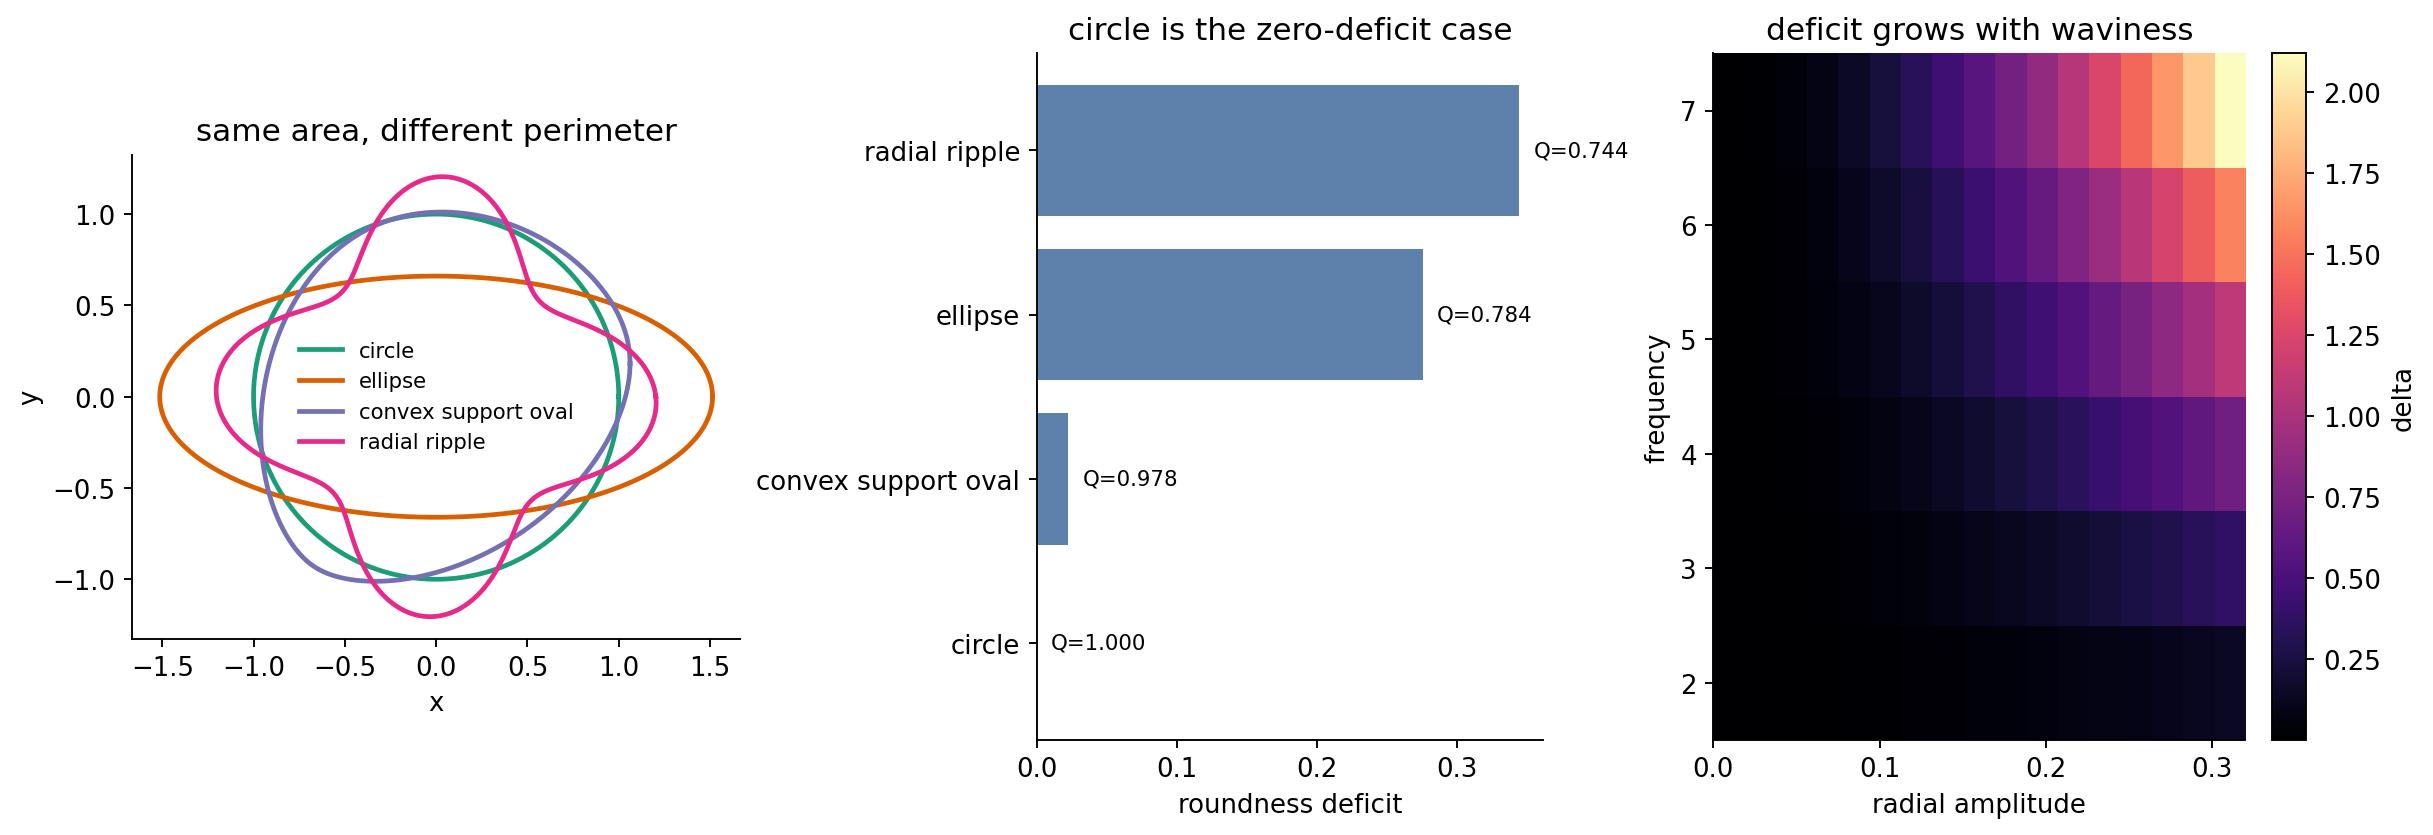

Checks saved to `artifacts/chapter-03/checks/isoperimetric-roundness.json`

In [6]:
iso_t = np.linspace(0.0, TWO_PI, 1400, endpoint=False)
raw_shapes = {
    "circle": circle_curve(iso_t, radius=1.0),
    "ellipse": ellipse_curve(iso_t, a=1.65, b=0.72),
    "convex support oval": support_oval(iso_t, a=0.05, b=0.09)[0],
    "radial ripple": radial_curve(iso_t, terms=[(0.22, 4, 0.15)]),
}
iso_shapes = {name: normalize_to_area(points, np.pi) for name, points in raw_shapes.items()}
iso_rows = []
for name, points in iso_shapes.items():
    row = {"shape": name, **isoperimetric_metrics(points)}
    iso_rows.append(row)
iso_df = pd.DataFrame(iso_rows).sort_values("roundness_deficit")

amplitudes = np.linspace(0.0, 0.32, 17)
frequencies = np.arange(2, 8)
deficit_grid = np.zeros((len(frequencies), len(amplitudes)))
for i, freq in enumerate(frequencies):
    for j, amp in enumerate(amplitudes):
        pts = radial_curve(iso_t, terms=[(float(amp), int(freq), 0.0)])
        deficit_grid[i, j] = isoperimetric_metrics(pts)["roundness_deficit"]

fig, axes = plt.subplots(1, 3, figsize=(14.2, 4.8), gridspec_kw={"width_ratios": [1.2, 1.0, 1.05]}, constrained_layout=True)
ax = axes[0]
colors = ["#1b9e77", "#d95f02", "#7570b3", "#e7298a"]
for color, (name, points) in zip(colors, iso_shapes.items()):
    p_closed = close_points(points)
    ax.plot(p_closed[:, 0], p_closed[:, 1], lw=2.0, color=color, label=name)
ax.set_aspect("equal")
ax.set_title("same area, different perimeter")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend(frameon=False, fontsize=9)

ax = axes[1]
ax.barh(iso_df["shape"], iso_df["roundness_deficit"], color="#5e81ac")
ax.set_xlabel("roundness deficit")
ax.set_title("circle is the zero-deficit case")
for y, value in enumerate(iso_df["isoperimetric_quotient"]):
    ax.text(iso_df["roundness_deficit"].iloc[y] + 0.01, y, f"Q={value:.3f}", va="center", fontsize=9)

ax = axes[2]
image = ax.imshow(deficit_grid, origin="lower", aspect="auto", cmap="magma", extent=[amplitudes.min(), amplitudes.max(), frequencies.min() - 0.5, frequencies.max() + 0.5])
ax.set_xlabel("radial amplitude")
ax.set_ylabel("frequency")
ax.set_title("deficit grows with waviness")
fig.colorbar(image, ax=ax, label="delta")

iso_path = FIGURE_DIR / "isoperimetric-roundness-deficit.png"
fig.savefig(iso_path, dpi=170, bbox_inches="tight")
plt.close(fig)

amp_values = np.linspace(0.0, 0.32, 9)
frames = []
for amp in amp_values:
    pts = radial_curve(iso_t, terms=[(float(amp), 4, 0.0)])
    metrics = isoperimetric_metrics(pts)
    p_closed = close_points(pts)
    frames.append(go.Frame(
        name=f"{amp:.2f}",
        data=[go.Scatter(x=p_closed[:, 0], y=p_closed[:, 1], mode="lines", line={"color": "#4c78a8", "width": 3})],
        layout=go.Layout(title_text=f"r(t)=1+{amp:.2f} cos(4t); Q={metrics['isoperimetric_quotient']:.4f}; delta={metrics['roundness_deficit']:.4f}"),
    ))
start = close_points(radial_curve(iso_t, terms=[(float(amp_values[0]), 4, 0.0)]))
plotly_fig = go.Figure(
    data=[go.Scatter(x=start[:, 0], y=start[:, 1], mode="lines", line={"color": "#4c78a8", "width": 3})],
    frames=frames,
)
plotly_fig.update_layout(
    title="Roundness-deficit sweep for a four-lobed radial perturbation",
    xaxis={"scaleanchor": "y", "range": [-1.45, 1.45], "zeroline": False},
    yaxis={"range": [-1.45, 1.45], "zeroline": False},
    width=760,
    height=560,
    sliders=[{
        "active": 0,
        "currentvalue": {"prefix": "amplitude "},
        "steps": [{"label": f"{amp:.2f}", "method": "animate", "args": [[f"{amp:.2f}"], {"mode": "immediate", "frame": {"duration": 0, "redraw": True}, "transition": {"duration": 0}}]} for amp in amp_values],
    }],
)
roundness_html_path = INTERACTIVE_DIR / "roundness-deficit-family.html"
plotly_fig.write_html(roundness_html_path, include_plotlyjs="cdn", full_html=True)

iso_check = {
    "artifact": "figures/isoperimetric-roundness-deficit.png",
    "interactive_artifact": "interactive/roundness-deficit-family.html",
    "shape_metrics": iso_df.to_dict(orient="records"),
    "max_quotient": float(iso_df["isoperimetric_quotient"].max()),
    "min_deficit": float(iso_df["roundness_deficit"].min()),
    "deficit_grid_min": float(deficit_grid.min()),
    "deficit_grid_max": float(deficit_grid.max()),
}
iso_check_path = save_json_artifact(iso_check, "isoperimetric-roundness.json")

assert iso_check["max_quotient"] <= 1.0 + 2e-3
assert iso_df.iloc[0]["shape"] == "circle"

display_book_artifact(iso_path, width=980)
display_book_artifact(roundness_html_path, width="100%", height=540)
Markdown(f"Checks saved to `{book_rel(iso_check_path)}`")


## Proof Scaffold: Where Wirtinger Enters

Pressley's proof translates the isoperimetric gap into a sum of two nonnegative terms. After moving the base point to the origin and using a period `pi` parameter, the equality model has `r(t)=D sin(t)` and `theta_dot=1`. The figure below does not replace the proof; it makes the bookkeeping visible.

The radial residual is the Wirtinger part, `int(rdot^2-r^2) dt`. The angular residual is `int r^2(theta_dot-1)^2 dt`. Both must vanish in the circular equality case.


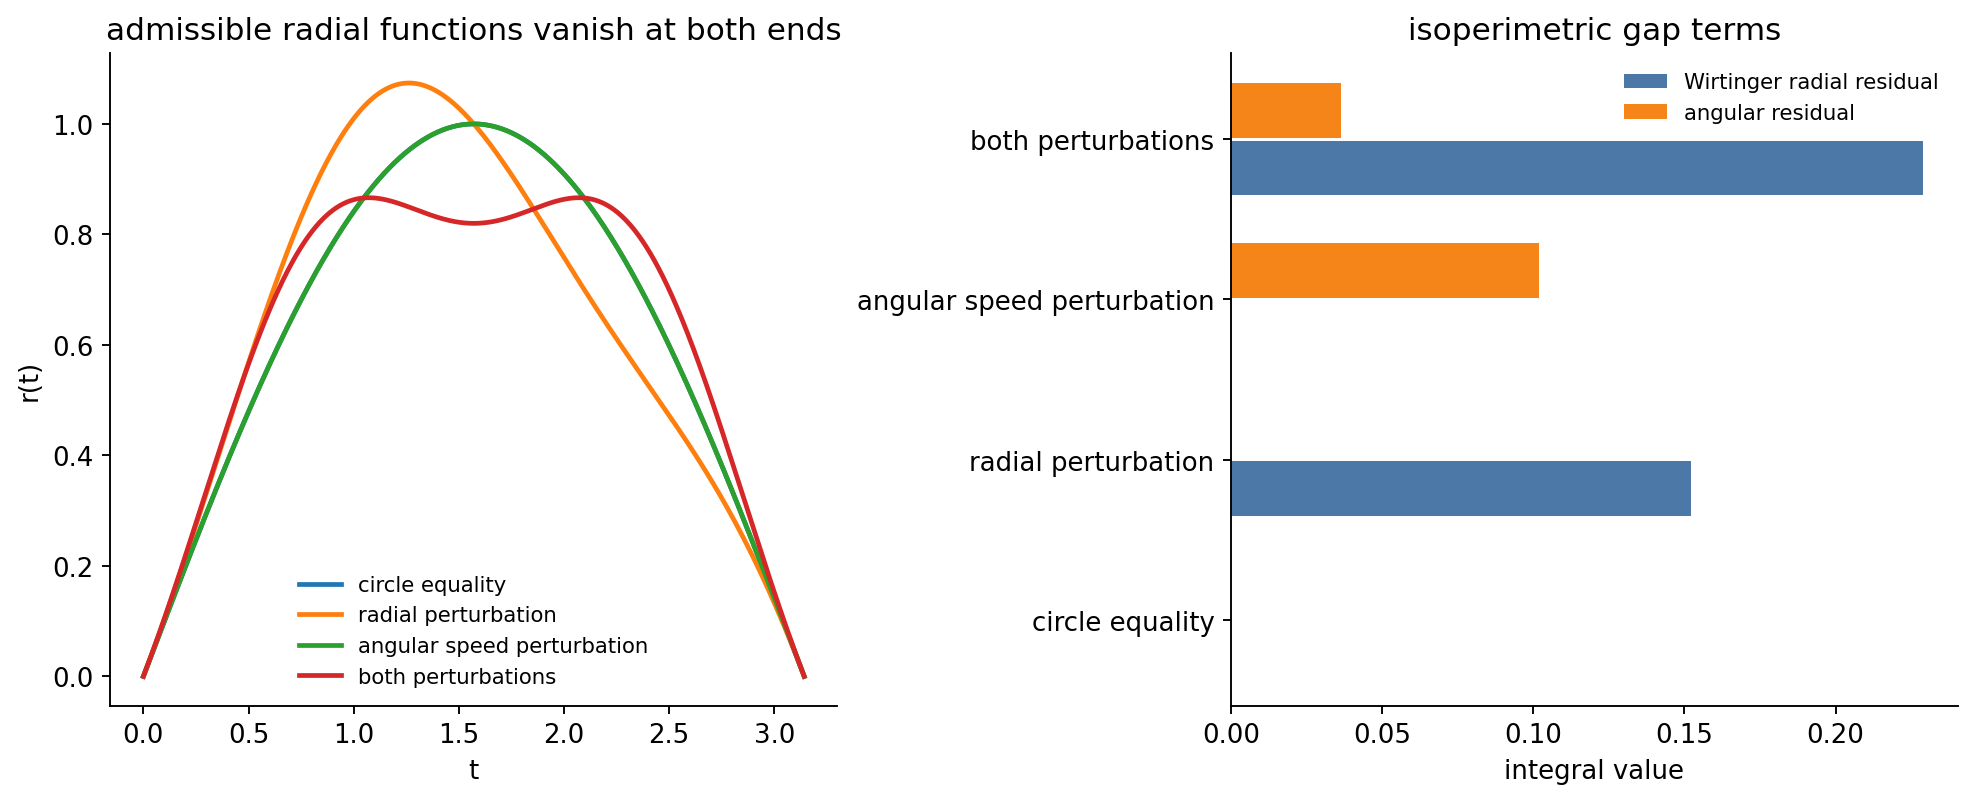

Checks saved to `artifacts/chapter-03/checks/wirtinger-decomposition.json`

In [7]:
wir_t = np.linspace(0.0, np.pi, 1600)

def wirtinger_case(label: str, eps: float = 0.0, mode: int = 2, twist: float = 0.0) -> dict:
    r = np.sin(wir_t) * (1.0 + eps * np.sin(mode * wir_t))
    rdot = np.gradient(r, wir_t)
    theta_dot = 1.0 + twist * 2.0 * np.cos(2.0 * wir_t)
    radial = float(np.trapezoid(rdot * rdot - r * r, wir_t))
    angular = float(np.trapezoid(r * r * (theta_dot - 1.0) ** 2, wir_t))
    return {"label": label, "r": r, "theta_dot": theta_dot, "radial": radial, "angular": angular, "I": radial + angular}

wir_cases = [
    wirtinger_case("circle equality", eps=0.0, twist=0.0),
    wirtinger_case("radial perturbation", eps=0.22, mode=2, twist=0.0),
    wirtinger_case("angular speed perturbation", eps=0.0, twist=0.18),
    wirtinger_case("both perturbations", eps=0.18, mode=3, twist=0.12),
]

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6), constrained_layout=True)
ax = axes[0]
for case in wir_cases:
    ax.plot(wir_t, case["r"], lw=2.0, label=case["label"])
ax.set_title("admissible radial functions vanish at both ends")
ax.set_xlabel("t")
ax.set_ylabel("r(t)")
ax.legend(frameon=False, fontsize=9)

ax = axes[1]
labels = [case["label"] for case in wir_cases]
radial_values = [case["radial"] for case in wir_cases]
angular_values = [case["angular"] for case in wir_cases]
y = np.arange(len(labels))
ax.barh(y - 0.18, radial_values, height=0.34, color="#4c78a8", label="Wirtinger radial residual")
ax.barh(y + 0.18, angular_values, height=0.34, color="#f58518", label="angular residual")
ax.set_yticks(y, labels)
ax.set_xlabel("integral value")
ax.set_title("isoperimetric gap terms")
ax.legend(frameon=False, fontsize=9)

wir_path = FIGURE_DIR / "isoperimetric-proof-decomposition.png"
fig.savefig(wir_path, dpi=170, bbox_inches="tight")
plt.close(fig)

wir_check = {
    "artifact": "figures/isoperimetric-proof-decomposition.png",
    "cases": [{k: v for k, v in case.items() if k not in {"r", "theta_dot"}} for case in wir_cases],
    "equality_case_abs_I": abs(wir_cases[0]["I"]),
    "all_perturbed_positive": all(case["I"] > 1e-4 for case in wir_cases[1:]),
}
wir_check_path = save_json_artifact(wir_check, "wirtinger-decomposition.json")
assert wir_check["equality_case_abs_I"] < 2e-3
assert wir_check["all_perturbed_positive"]

display_book_artifact(wir_path, width=920)
Markdown(f"Checks saved to `{book_rel(wir_check_path)}`")


## 3.3 Curvature Extrema And Four-Vertex Experiments

A vertex is a stationary point of signed curvature. The ellipse gives the cleanest benchmark: two curvature maxima and two minima occur at the ends of the axes. The theorem in the chapter says a convex simple closed curve cannot have fewer than four vertices.

The experiment below compares three cases:

- an ellipse, with exactly four vertices;
- a support-function oval with positive radius of curvature, hence convex, with six vertices in this sample;
- a self-crossing limacon, where the four-vertex hypothesis is deliberately broken and the vertex count drops to two.


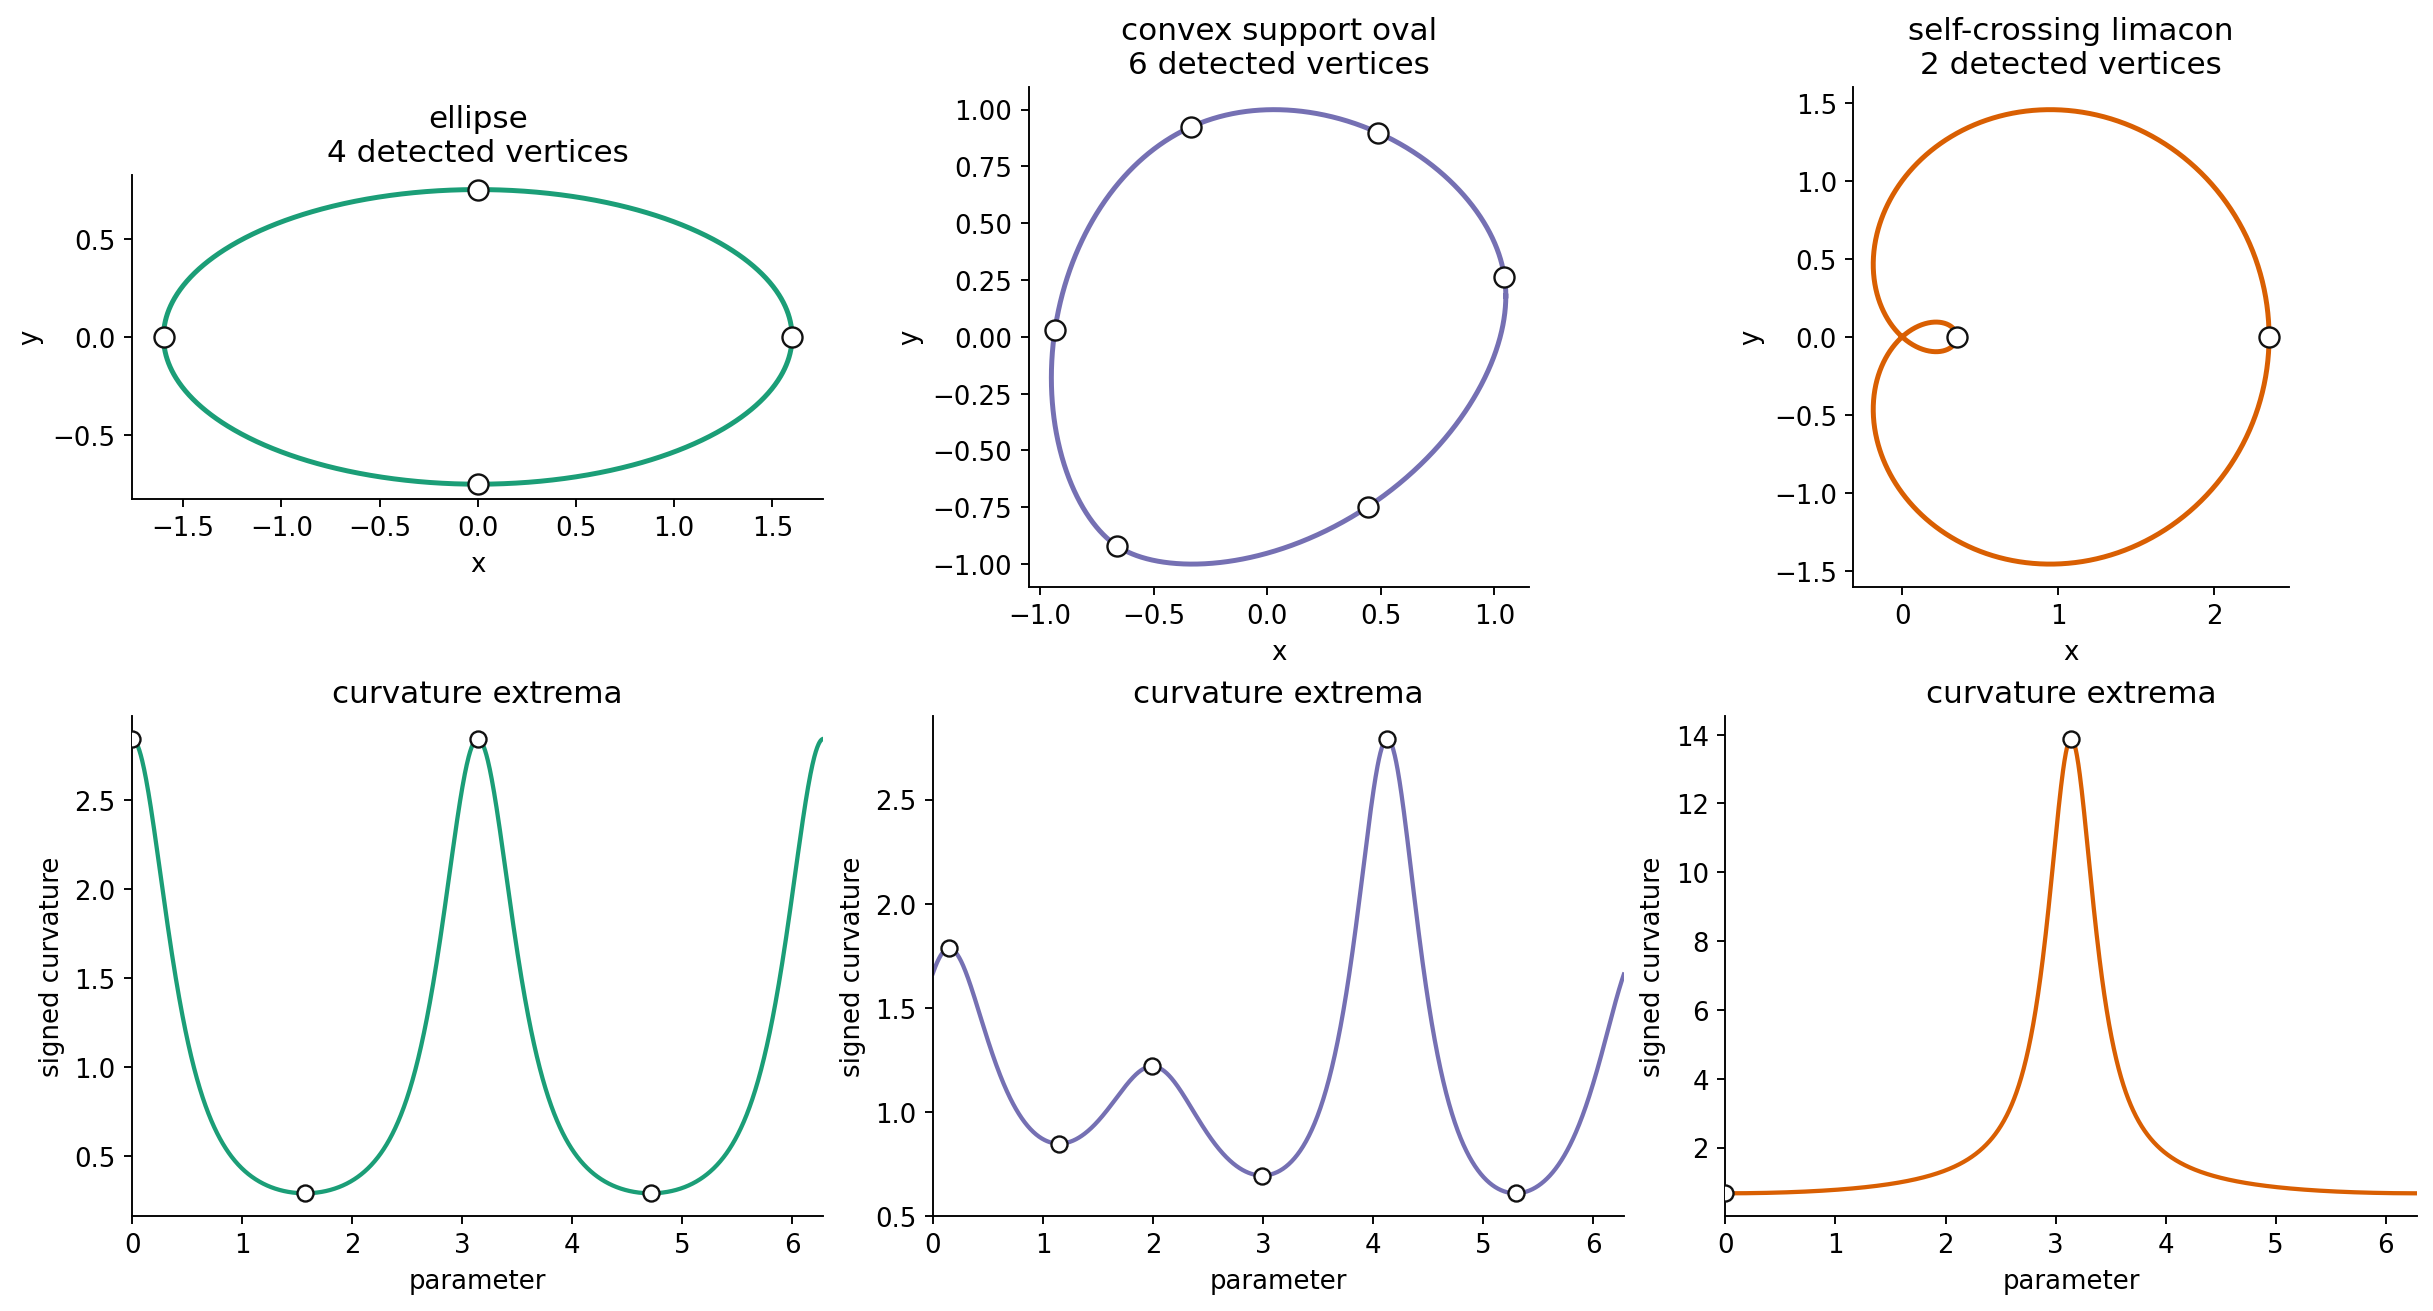

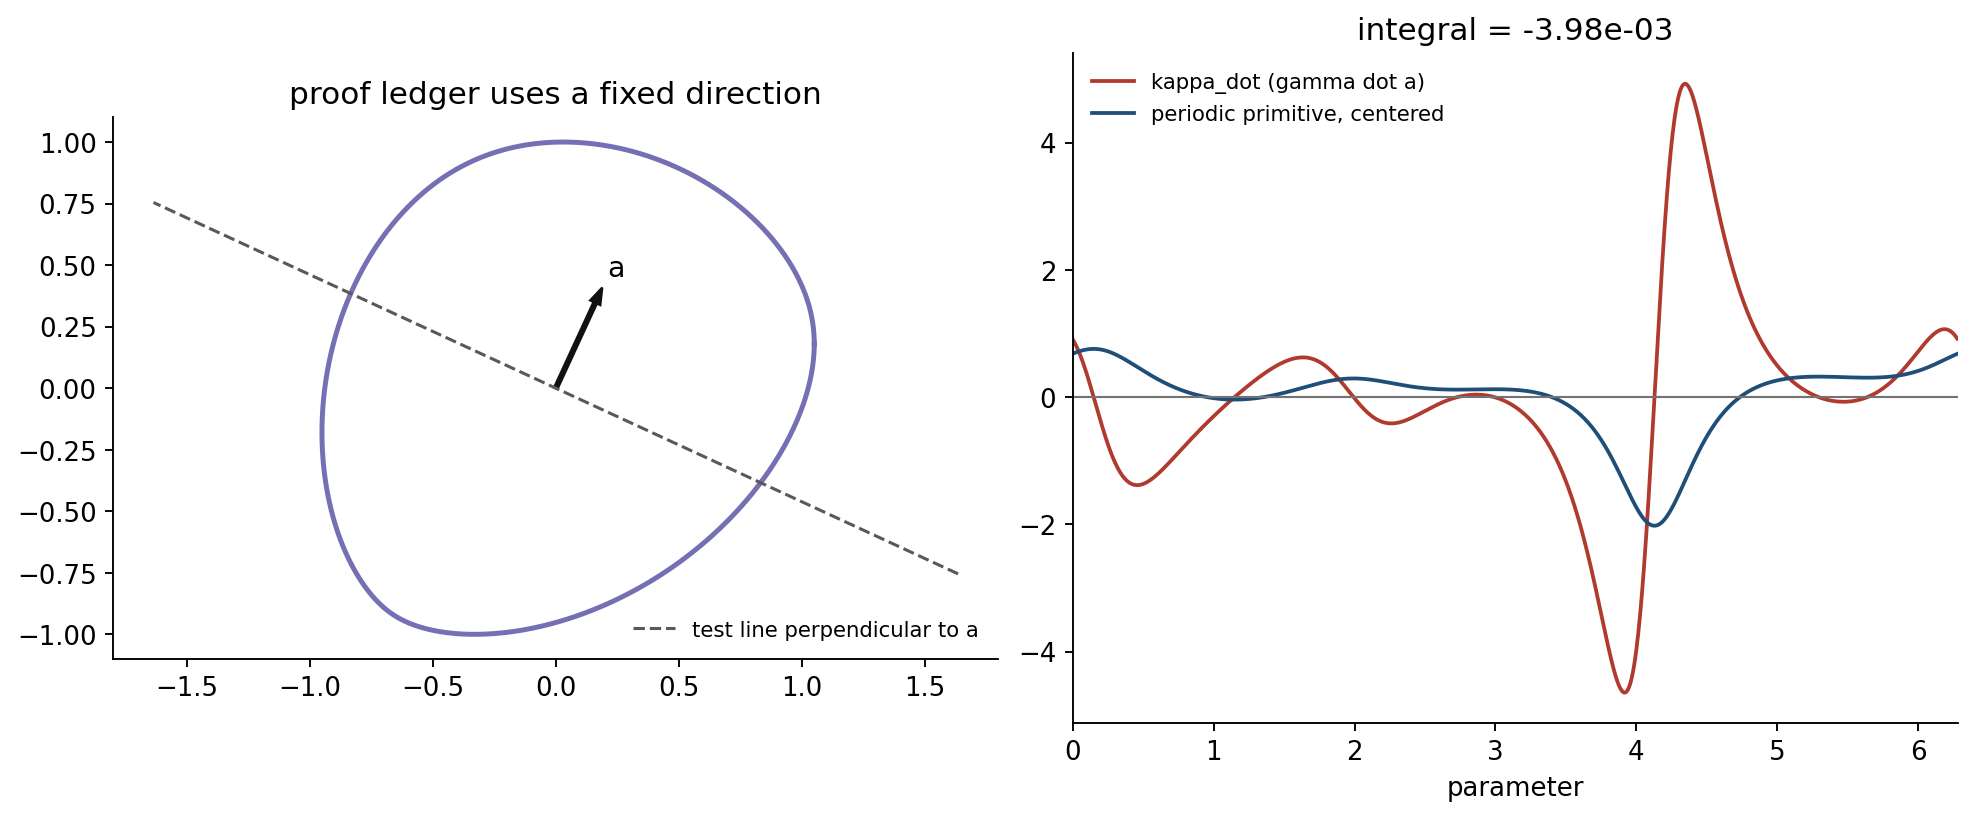

Checks saved to `artifacts/chapter-03/checks/four-vertex-experiments.json`

In [8]:
vertex_t = np.linspace(0.0, TWO_PI, 1440, endpoint=False)
vertex_examples = []

ellipse_pts = ellipse_curve(vertex_t, a=1.6, b=0.75)
ellipse_kappa, ellipse_speed = curvature_from_points(ellipse_pts, vertex_t)
vertex_examples.append({"name": "ellipse", "points": ellipse_pts, "kappa": ellipse_kappa, "validity": polygon_validity(ellipse_pts), "convex_expected": True})

support_pts, support_rho = support_oval(vertex_t, a=0.05, b=0.09)
support_kappa = 1.0 / support_rho
vertex_examples.append({"name": "convex support oval", "points": support_pts, "kappa": support_kappa, "validity": polygon_validity(support_pts), "min_radius_of_curvature": float(support_rho.min()), "convex_expected": True})

limacon_pts = limacon_curve(vertex_t, a=1.35)
limacon_kappa, _ = curvature_from_points(limacon_pts, vertex_t)
vertex_examples.append({"name": "self-crossing limacon", "points": limacon_pts, "kappa": limacon_kappa, "validity": polygon_validity(limacon_pts), "convex_expected": False})

for example in vertex_examples:
    indices = periodic_extrema_indices(example["kappa"], prominence_fraction=0.02, distance_fraction=1 / 20)
    example["vertex_indices"] = indices
    example["vertex_count"] = int(len(indices))
    example["total_turn"] = total_turn(example["points"], vertex_t)
    example["metrics"] = isoperimetric_metrics(example["points"])

fig, axes = plt.subplots(2, 3, figsize=(14.2, 7.6), constrained_layout=True)
colors = ["#1b9e77", "#7570b3", "#d95f02"]
for col, (example, color) in enumerate(zip(vertex_examples, colors)):
    pts = example["points"]
    p_closed = close_points(pts)
    vertices = example["vertex_indices"]
    ax = axes[0, col]
    ax.plot(p_closed[:, 0], p_closed[:, 1], color=color, lw=2.1)
    ax.scatter(pts[vertices, 0], pts[vertices, 1], s=72, color="#111111", facecolor="white", zorder=4)
    ax.set_title(f"{example['name']}\n{example['vertex_count']} detected vertices")
    ax.set_aspect("equal")
    ax.set_xlabel("x")
    ax.set_ylabel("y")

    ax = axes[1, col]
    ax.plot(vertex_t, example["kappa"], color=color, lw=1.8)
    ax.scatter(vertex_t[vertices], example["kappa"][vertices], s=46, color="#111111", facecolor="white", zorder=4)
    ax.set_xlim(0, TWO_PI)
    ax.set_xlabel("parameter")
    ax.set_ylabel("signed curvature")
    ax.set_title("curvature extrema")

vertex_path = FIGURE_DIR / "four-vertex-curvature-extrema.png"
fig.savefig(vertex_path, dpi=170, bbox_inches="tight")
plt.close(fig)

ledger_points = support_pts
ledger_kappa = support_kappa
tangent, normal, speed = unit_tangent_normal(ledger_points, vertex_t)
step = float(vertex_t[1] - vertex_t[0])
kappa_t, _ = periodic_derivatives(ledger_kappa, step)
a_vec = np.array([0.42, 0.91])
a_vec = a_vec / np.linalg.norm(a_vec)
lambda_values = (ledger_kappa[:, None] * ledger_points + normal) @ a_vec
integrand_values = kappa_t * (ledger_points @ a_vec)
lambda_t = np.gradient(lambda_values, vertex_t)
ledger_integral = float(np.trapezoid(integrand_values, vertex_t))
lambda_residual = float(np.max(np.abs(lambda_t - integrand_values)))

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.7), constrained_layout=True)
ax = axes[0]
p_closed = close_points(ledger_points)
ax.plot(p_closed[:, 0], p_closed[:, 1], color="#7570b3", lw=2.1)
origin = ledger_points.mean(axis=0)
line_span = np.array([-1.8, 1.8])
perp = np.array([-a_vec[1], a_vec[0]])
line = origin + line_span[:, None] * perp
ax.plot(line[:, 0], line[:, 1], color="0.35", ls="--", lw=1.3, label="test line perpendicular to a")
ax.arrow(origin[0], origin[1], 0.45 * a_vec[0], 0.45 * a_vec[1], width=0.015, color="#111111", length_includes_head=True)
ax.text(origin[0] + 0.5 * a_vec[0], origin[1] + 0.5 * a_vec[1], "a", fontsize=12)
ax.set_aspect("equal")
ax.set_title("proof ledger uses a fixed direction")
ax.legend(frameon=False, fontsize=9)

ax = axes[1]
ax.plot(vertex_t, integrand_values, color="#b03a2e", lw=1.6, label="kappa_dot (gamma dot a)")
ax.plot(vertex_t, lambda_values - lambda_values.mean(), color="#1f4e79", lw=1.6, label="periodic primitive, centered")
ax.axhline(0, color="0.45", lw=0.9)
ax.set_xlim(0, TWO_PI)
ax.set_title(f"integral = {ledger_integral:.2e}")
ax.set_xlabel("parameter")
ax.legend(frameon=False, fontsize=9)

ledger_path = FIGURE_DIR / "four-vertex-integral-ledger.png"
fig.savefig(ledger_path, dpi=170, bbox_inches="tight")
plt.close(fig)

vertex_check = {
    "artifacts": ["figures/four-vertex-curvature-extrema.png", "figures/four-vertex-integral-ledger.png"],
    "examples": [
        {
            "name": ex["name"],
            "vertex_count": ex["vertex_count"],
            "polygon_valid": ex["validity"]["polygon_valid"],
            "boundary_simple": ex["validity"]["boundary_simple"],
            "total_turn_over_2pi": ex["total_turn"] / TWO_PI,
            "isoperimetric_quotient": ex["metrics"]["isoperimetric_quotient"],
            "roundness_deficit": ex["metrics"]["roundness_deficit"],
            "min_radius_of_curvature": ex.get("min_radius_of_curvature"),
        }
        for ex in vertex_examples
    ],
    "convex_examples_have_at_least_four_vertices": all(ex["vertex_count"] >= 4 for ex in vertex_examples if ex["convex_expected"]),
    "self_crossing_example_has_two_vertices": int(vertex_examples[-1]["vertex_count"]) == 2,
    "ledger_integral": ledger_integral,
    "lambda_derivative_residual": lambda_residual,
}
vertex_check_path = save_json_artifact(vertex_check, "four-vertex-experiments.json")
assert vertex_check["convex_examples_have_at_least_four_vertices"]
assert vertex_check["self_crossing_example_has_two_vertices"]
assert abs(vertex_check["ledger_integral"]) < 5e-3

display_book_artifact(vertex_path, width=980)
display_book_artifact(ledger_path, width=920)
Markdown(f"Checks saved to `{book_rel(vertex_check_path)}`")


## Applied Lab: Compare Global Curve Metrics

The lab table is meant to be edited. Add a new periodic curve, then check which claims are still true. The columns separate local data from global data: a curve can have a regular curvature calculation but still fail simplicity, convexity, or the isoperimetric equality case.


In [9]:
lab_t = np.linspace(0.0, TWO_PI, 1800, endpoint=False)
lab_curves = {
    "circle": circle_curve(lab_t),
    "ellipse": ellipse_curve(lab_t, a=1.6, b=0.75),
    "convex support oval": support_oval(lab_t, a=0.05, b=0.09)[0],
    "simple radial ripple": radial_curve(lab_t, terms=[(0.24, 5, 0.1)]),
    "self-crossing limacon": limacon_curve(lab_t, a=1.35),
}
lab_rows = []
for name, pts in lab_curves.items():
    kappa, speed = curvature_from_points(pts, lab_t)
    extrema = periodic_extrema_indices(kappa, prominence_fraction=0.02, distance_fraction=1 / 24)
    metrics = isoperimetric_metrics(pts)
    validity = polygon_validity(pts)
    lab_rows.append({
        "curve": name,
        "closed_gap": float(np.linalg.norm(close_points(pts)[0] - close_points(pts)[-1])),
        "boundary_simple": validity["boundary_simple"],
        "polygon_valid": validity["polygon_valid"],
        "area": metrics["area"],
        "length": metrics["length"],
        "Q_4piA_over_L2": metrics["isoperimetric_quotient"],
        "roundness_deficit": metrics["roundness_deficit"],
        "convexity_area_ratio": metrics["convexity_area_ratio"],
        "total_turn_over_2pi": total_turn(pts, lab_t) / TWO_PI,
        "vertex_count_detected": int(len(extrema)),
        "curvature_min": float(np.nanmin(kappa)),
        "curvature_max": float(np.nanmax(kappa)),
    })

lab_df = pd.DataFrame(lab_rows).sort_values(["polygon_valid", "roundness_deficit"], ascending=[False, True])
lab_csv_path = TABLE_DIR / "curve-global-metrics.csv"
lab_df.to_csv(lab_csv_path, index=False)
lab_check_path = save_json_artifact({
    "table": "tables/curve-global-metrics.csv",
    "row_count": int(len(lab_df)),
    "simple_valid_rows": int(lab_df["polygon_valid"].sum()),
    "circle_deficit": float(lab_df.loc[lab_df["curve"] == "circle", "roundness_deficit"].iloc[0]),
    "max_valid_Q": float(lab_df.loc[lab_df["polygon_valid"], "Q_4piA_over_L2"].max()),
}, "chapter-03-metrics.json")

display(lab_df.style.format({
    "closed_gap": "{:.2e}",
    "area": "{:.4f}",
    "length": "{:.4f}",
    "Q_4piA_over_L2": "{:.5f}",
    "roundness_deficit": "{:.5f}",
    "convexity_area_ratio": "{:.4f}",
    "total_turn_over_2pi": "{:.3f}",
    "curvature_min": "{:.4f}",
    "curvature_max": "{:.4f}",
}))
Markdown(f"Lab data saved to `{book_rel(lab_csv_path)}` and `{book_rel(lab_check_path)}`")


,curve,closed_gap,boundary_simple,polygon_valid,area,length,Q_4piA_over_L2,roundness_deficit,convexity_area_ratio,total_turn_over_2pi,vertex_count_detected,curvature_min,curvature_max
0,circle,0.00e+00,True,True,3.1416,6.2832,1.00000,0.00000,1.0000,1.000,0,1.0000,1.0000
2,convex support oval,0.00e+00,True,True,3.0720,6.2832,0.97785,0.02265,1.0000,1.000,6,0.6091,2.7921
1,ellipse,0.00e+00,True,True,3.7699,7.6262,0.81455,0.22767,1.0000,1.000,4,0.2930,2.8445
3,simple radial ripple,0.00e+00,True,True,3.2321,8.1620,0.60966,0.64025,0.8176,1.000,10,-9.0698,4.7087
4,self-crossing limacon,0.00e+00,False,False,6.0043,9.6929,0.80310,0.24517,0.9994,2.000,2,0.6700,13.8782


Lab data saved to `artifacts/chapter-03/tables/curve-global-metrics.csv` and `artifacts/chapter-03/checks/chapter-03-metrics.json`

## Final Sanity Checks

These checks are intentionally redundant. They validate the visible artifacts, the exact symbolic identities, the core numeric inequalities, and the four-vertex experiments that the chapter uses as evidence.


In [10]:
expected_artifacts = [
    FIGURE_DIR / "simple-closed-orientation-winding.png",
    FIGURE_DIR / "oriented-area-green-computation.png",
    FIGURE_DIR / "isoperimetric-roundness-deficit.png",
    INTERACTIVE_DIR / "roundness-deficit-family.html",
    FIGURE_DIR / "isoperimetric-proof-decomposition.png",
    FIGURE_DIR / "four-vertex-curvature-extrema.png",
    FIGURE_DIR / "four-vertex-integral-ledger.png",
    CHECK_DIR / "source-span.json",
    CHECK_DIR / "visual-storyboard.json",
    CHECK_DIR / "simple-closed-orientation.json",
    CHECK_DIR / "green-area-computation.json",
    CHECK_DIR / "ellipse-symbolic-green-curvature.json",
    CHECK_DIR / "isoperimetric-roundness.json",
    CHECK_DIR / "wirtinger-decomposition.json",
    CHECK_DIR / "four-vertex-experiments.json",
    CHECK_DIR / "chapter-03-metrics.json",
    TABLE_DIR / "curve-global-metrics.csv",
]
for artifact in expected_artifacts:
    assert_artifact(artifact, min_bytes=256 if artifact.suffix.lower() in {".png", ".html"} else 32)

assert abs(simple_check["inside_probe_winding"] - 1.0) < 0.05
assert abs(simple_check["outside_probe_winding"]) < 0.05
assert simple_check["simple_loop"]["polygon_valid"] and simple_check["simple_loop"]["boundary_simple"]
assert not simple_check["self_crossing_loop"]["boundary_simple"]
assert abs(simple_check["simple_total_turn"] - TWO_PI) < 2e-2

assert symbolic_check["area_equals_pi_p_q"]
assert abs(area_check["green_minus_shoelace"]) < 3e-3
assert abs(area_check["shoelace_minus_polygon_abs"]) < 3e-3
assert area_check["green_area"] > 0 and area_check["reverse_orientation_area"] < 0

assert iso_check["max_quotient"] <= 1.0 + 2e-3
assert iso_check["min_deficit"] < 2e-3
assert wir_check["equality_case_abs_I"] < 2e-3
assert wir_check["all_perturbed_positive"]

assert vertex_check["convex_examples_have_at_least_four_vertices"]
assert vertex_check["self_crossing_example_has_two_vertices"]
assert abs(vertex_check["ledger_integral"]) < 5e-3
assert lab_df.loc[lab_df["polygon_valid"], "Q_4piA_over_L2"].max() <= 1.0 + 2e-3

banned_builder_name = "build_" + "unit_visuals"
assert banned_builder_name not in NOTEBOOK_PATH.read_text(encoding="utf-8")

final_sanity = {
    "source_span": SOURCE_SPAN,
    "artifact_count": len(expected_artifacts),
    "artifacts": [book_rel(path) for path in expected_artifacts],
    "green_area_residual": abs(area_check["green_minus_shoelace"]),
    "max_isoperimetric_quotient": iso_check["max_quotient"],
    "min_roundness_deficit": iso_check["min_deficit"],
    "convex_vertex_counts": [ex["vertex_count"] for ex in vertex_examples if ex["convex_expected"]],
    "self_crossing_vertex_count": vertex_examples[-1]["vertex_count"],
    "ledger_integral": vertex_check["ledger_integral"],
    "no_generic_visual_builder": True,
}
final_sanity_path = save_json_artifact(final_sanity, "final-sanity.json")
notebook_sanity_path = CHECK_DIR / "notebook-sanity.json"
notebook_sanity_path.write_text(json.dumps(final_sanity, indent=2, sort_keys=True), encoding="utf-8")
assert_artifact(final_sanity_path, min_bytes=32)
assert_artifact(notebook_sanity_path, min_bytes=32)
final_sanity


{'source_span': {'printed': '55-66', 'pdf': '64-74', 'sections': '3.1-3.3'},
 'artifact_count': 17,
 'artifacts': ['artifacts/chapter-03/figures/simple-closed-orientation-winding.png',
  'artifacts/chapter-03/figures/oriented-area-green-computation.png',
  'artifacts/chapter-03/figures/isoperimetric-roundness-deficit.png',
  'artifacts/chapter-03/interactive/roundness-deficit-family.html',
  'artifacts/chapter-03/figures/isoperimetric-proof-decomposition.png',
  'artifacts/chapter-03/figures/four-vertex-curvature-extrema.png',
  'artifacts/chapter-03/figures/four-vertex-integral-ledger.png',
  'artifacts/chapter-03/checks/source-span.json',
  'artifacts/chapter-03/checks/visual-storyboard.json',
  'artifacts/chapter-03/checks/simple-closed-orientation.json',
  'artifacts/chapter-03/checks/green-area-computation.json',
  'artifacts/chapter-03/checks/ellipse-symbolic-green-curvature.json',
  'artifacts/chapter-03/checks/isoperimetric-roundness.json',
  'artifacts/chapter-03/checks/wirtin

## Takeaways

- A simple closed curve is a global object: closure, orientation, winding, and no self-intersection must be checked together.
- Green's theorem turns enclosed area into boundary data, so the sign of area is an orientation test as well as a measurement.
- The isoperimetric quotient and roundness deficit make the circle's equality case numerically visible and scale-invariant.
- Pressley's proof reduces the isoperimetric gap to nonnegative radial and angular residuals; equality leaves no freedom except the circle model.
- Vertices are curvature extrema. Convex simple closed experiments obey the four-vertex lower bound, while the self-crossing limacon shows why global hypotheses cannot be treated as decoration.
